In [35]:
import sys
sys.path.append("..")

In [36]:
# Proper MLM inference: mask motifs and predict them
import torch, pandas as pd, re, torch.nn.functional as F, os
from modules.custom_bert import DNABertForMaskedLM  
from modules.dna_tokenizer import DNATokenizer
from modules.bert_config import BertConfig
from safetensors.torch import load_file

os.chdir('/home/shishir-sunar/InsDelGLM')

# Load model
with open("model/Tiger_baseline_100k_1e-5/vocab.txt", "r") as f:
    vocab = [line.strip() for line in f]
tokenizer = DNATokenizer(vocab=vocab, deletion_token=False)
model = DNABertForMaskedLM(BertConfig.from_json_file("model/Tiger_baseline_100k_1e-5/config.json"))
model.load_state_dict(load_file("model/Tiger_baseline_100k_1e-5/model.safetensors"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

test_data = pd.read_parquet("data/simulated/baseline_test.parquet")
motifs = ["CGTAGGTC", "GTAACGCTCC"]
mask_id = tokenizer._convert_token_to_id('[MASK]')
cls_id = tokenizer._convert_token_to_id('[CLS]')
sep_id = tokenizer._convert_token_to_id('[SEP]')

def proper_mlm_test(seq, model, motifs, tokenizer, device):
    """Proper MLM: mask motifs and predict them (like training)"""
    losses = []
    
    for motif in motifs:
        for match in re.finditer(motif, seq):
            start, end = match.span()
            
            # Tokenize sequence properly with [CLS] and [SEP]
            tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
            input_ids = [cls_id] + tokens + [sep_id]
            
            # Mask the motif positions (offset by 1 for [CLS])
            masked_input = input_ids.copy()
            motif_start_idx = start + 1  # +1 for [CLS] token
            motif_tokens = [tokenizer._convert_token_to_id(c) for c in motif]
            
            # Replace motif tokens with [MASK]
            for i in range(len(motif)):
                if motif_start_idx + i < len(masked_input) - 1:  # Don't mask [SEP]
                    masked_input[motif_start_idx + i] = mask_id
            
            # Get predictions
            with torch.no_grad():
                logits = model(torch.tensor([masked_input], device=device), return_dict=True).logits[0]
            
            # Calculate loss only on masked positions
            pred_logits = logits[motif_start_idx:motif_start_idx + len(motif_tokens)]
            ground_truth = torch.tensor(motif_tokens, device=device)
            
            if len(pred_logits) == len(ground_truth):
                loss = F.cross_entropy(pred_logits, ground_truth)
                losses.append(loss.item())
                print(f"Motif '{motif}' at {start}-{end}: loss = {loss:.4f}")
    
    return sum(losses) / len(losses) if losses else 0

def proper_mlm_test_refined(seq, model, motifs, tokenizer, device):
    # 1. Use the tokenizer's proper encoding (handles k-mers/special tokens)
    # This ensures the input matches training format exactly.
    enc = tokenizer.encode_plus(seq, add_special_tokens=True, return_tensors="pt")
    input_ids = enc['input_ids'].to(device)
    labels = input_ids.clone()
    
    # 2. Find motif in the original string to get character indices
    for motif in motifs:
        for match in re.finditer(motif, seq):
            char_start, char_end = match.span()
            
            # 3. Map character indices to token indices
            # (Crucial if using k-mers where 1 token = multiple characters)
            token_start = enc.char_to_token(char_start)
            token_end = enc.char_to_token(char_end - 1)
            
            if token_start is None or token_end is None:
                continue

            # Mask only the motif tokens
            masked_input = input_ids.clone()
            masked_input[0, token_start : token_end + 1] = mask_id
            
            with torch.no_grad():
                outputs = model(masked_input)
                logits = outputs.logits[0]
            
            # Calculate loss
            mask_logits = logits[token_start : token_end + 1]
            mask_labels = labels[0, token_start : token_end + 1]
            
            loss = F.cross_entropy(mask_logits, mask_labels)
            print(f"Motif '{motif}': Loss {loss.item():.4f}")

# Test
seq = test_data.iloc[5]['sequences']
print(f"Sequence: {seq}")
print(f"Motifs: {motifs}")
print("-" * 40)
loss = proper_mlm_test(seq, model, motifs, tokenizer, device)
print(f"Proper MLM cross-entropy at motifs: {loss:.4f}")

Sequence: TAGCCTACGTAACGCTCCAGGCGGTGCTCT
Motifs: ['CGTAGGTC', 'GTAACGCTCC']
----------------------------------------
Motif 'GTAACGCTCC' at 8-18: loss = 1.0960
Proper MLM cross-entropy at motifs: 1.0960


In [38]:
# Proper MLM inference for DELETION model with gaps
print("=" * 50)
print("DELETION MODEL (Tiger_gap_prob) - Proper MLM Test")
print("=" * 50)

# Load deletion model with gap support
with open("model/Tiger_deletion_100k_1e-5/vocab.txt", "r") as f:
    del_vocab = [line.strip() for line in f]
del_tokenizer = DNATokenizer(vocab=del_vocab, deletion_token=True)
del_model = DNABertForMaskedLM(BertConfig.from_json_file("model/Tiger_deletion_100k_1e-5/config.json"))
del_model.load_state_dict(load_file("model/Tiger_deletion_100k_1e-5/model.safetensors"))
del_model.to(device).eval()

# Load test data with gaps
del_test_data = pd.read_parquet("data/simulated/test.parquet")
del_mask_id = del_tokenizer._convert_token_to_id('[MASK]')
del_cls_id = del_tokenizer._convert_token_to_id('[CLS]')  
del_sep_id = del_tokenizer._convert_token_to_id('[SEP]')

print(f"Deletion vocab (with gaps): {del_vocab}")

def proper_mlm_test_with_gaps(seq, model, motifs, tokenizer, device):
    """Proper MLM for deletion model: mask motifs and predict them"""
    losses = []
    
    for motif in motifs:
        for match in re.finditer(motif, seq):
            start, end = match.span()
            
            # Tokenize sequence with gaps properly
            tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
            input_ids = [del_cls_id] + tokens + [del_sep_id]
            
            # Mask the motif positions (offset by 1 for [CLS])
            masked_input = input_ids.copy()
            motif_start_idx = start + 1  # +1 for [CLS] token
            motif_tokens = [tokenizer._convert_token_to_id(c) for c in motif]
            
            # Replace motif tokens with [MASK]
            for i in range(len(motif)):
                if motif_start_idx + i < len(masked_input) - 1:  # Don't mask [SEP]
                    masked_input[motif_start_idx + i] = del_mask_id
            
            # Get predictions
            with torch.no_grad():
                logits = model(torch.tensor([masked_input], device=device), return_dict=True).logits[0]
            
            # Calculate loss only on masked positions
            pred_logits = logits[motif_start_idx:motif_start_idx + len(motif_tokens)]
            ground_truth = torch.tensor(motif_tokens, device=device)
            
            if len(pred_logits) == len(ground_truth):
                loss = F.cross_entropy(pred_logits, ground_truth)
                losses.append(loss.item())
                print(f"Motif '{motif}' at {start}-{end}: loss = {loss:.4f}")
    
    return sum(losses) / len(losses) if losses else 0

# Test deletion model
del_seq = del_test_data.iloc[5]['sequences']
print(f"Sequence with gaps: {del_seq}")
print(f"Sequence has gaps: {'-' in del_seq}")
print(f"Motifs: {motifs}")
print("-" * 40)
del_loss = proper_mlm_test_with_gaps(del_seq, del_model, motifs, del_tokenizer, device)
print(f"Deletion model MLM cross-entropy at motifs: {del_loss:.4f}")

print("\n" + "=" * 50)
print("COMPARISON:")
print(f"Baseline model: {loss:.4f}")  
print(f"Deletion model: {del_loss:.4f}")
print("=" * 50)

DELETION MODEL (Tiger_gap_prob) - Proper MLM Test
Deletion vocab (with gaps): ['A', 'T', 'C', 'G', '-', '[PAD]', '[MASK]', '[CLS]', '[SEP]']
Sequence with gaps: TA-CCTACGTAACGCTCC-GG-GG-GCTCT
Sequence has gaps: True
Motifs: ['CGTAGGTC', 'GTAACGCTCC']
----------------------------------------
Motif 'GTAACGCTCC' at 8-18: loss = 2.0151
Deletion model MLM cross-entropy at motifs: 2.0151

COMPARISON:
Baseline model: 1.0960
Deletion model: 2.0151


In [39]:
# Random chunk testing for retrained baseline model
import random

def random_chunk_mlm_test(seq, model, tokenizer, device, num_tests=5, chunk_length=7):
    """Test random positions to compare with motif performance"""
    losses = []
    
    # Avoid motif regions for fair comparison
    motif_regions = []
    for motif in motifs:
        for match in re.finditer(motif, seq):
            start, end = match.span()
            motif_regions.extend(range(start, end))
    
    print(f"Testing {num_tests} random chunks of length {chunk_length}:")
    print("-" * 50)
    
    for test_num in range(num_tests):
        # Pick a random position that doesn't overlap with motifs
        available_positions = []
        for i in range(len(seq) - chunk_length + 1):
            chunk_range = range(i, i + chunk_length)
            if not any(pos in motif_regions for pos in chunk_range):
                available_positions.append(i)
        
        if not available_positions:
            print(f"No available positions for chunk {test_num + 1}")
            continue
            
        start = random.choice(available_positions)
        end = start + chunk_length
        random_chunk = seq[start:end]
        
        print(f"Chunk {test_num + 1}: '{random_chunk}' at positions {start}-{end}")
        
        # Tokenize sequence properly with [CLS] and [SEP]
        tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
        input_ids = [cls_id] + tokens + [sep_id]
        
        # Mask the random chunk positions (offset by 1 for [CLS])
        masked_input = input_ids.copy()
        chunk_start_idx = start + 1  # +1 for [CLS] token
        chunk_tokens = [tokenizer._convert_token_to_id(c) for c in random_chunk]
        
        # Replace chunk tokens with [MASK]
        for i in range(len(random_chunk)):
            if chunk_start_idx + i < len(masked_input) - 1:  # Don't mask [SEP]
                masked_input[chunk_start_idx + i] = mask_id
        
        # Get predictions
        with torch.no_grad():
            logits = model(torch.tensor([masked_input], device=device), return_dict=True).logits[0]
        
        # Calculate loss only on masked positions
        pred_logits = logits[chunk_start_idx:chunk_start_idx + len(chunk_tokens)]
        ground_truth = torch.tensor(chunk_tokens, device=device)
        
        if len(pred_logits) == len(ground_truth):
            loss = F.cross_entropy(pred_logits, ground_truth)
            losses.append(loss.item())
            
            # Get predicted tokens for comparison
            predicted_ids = torch.argmax(pred_logits, dim=-1)
            predicted_tokens = [tokenizer._convert_id_to_token(id.item()) for id in predicted_ids]
            print(f"  Predicted: {''.join(predicted_tokens)}")
            print(f"  Actual:    {random_chunk}")
            print(f"  Loss:      {loss:.4f}")
        else:
            print(f"  Shape mismatch - pred {len(pred_logits)} vs truth {len(ground_truth)}")
    
    return sum(losses) / len(losses) if losses else 0

print("RETRAINED BASELINE MODEL - MOTIF vs RANDOM COMPARISON")
print("=" * 60)

# Test the retrained baseline model on motifs (rerun to get fresh results)
print("\n1. MOTIF PERFORMANCE:")
print("-" * 30)
motif_loss = proper_mlm_test(seq, model, motifs, tokenizer, device)

print(f"\n2. RANDOM CHUNK PERFORMANCE:")
print("-" * 30)
random_loss = random_chunk_mlm_test(seq, model, tokenizer, device, num_tests=5, chunk_length=7)

print(f"\n3. COMPARISON RESULTS:")
print("=" * 30)
print(f"Average motif loss:      {motif_loss:.4f}")
print(f"Average random loss:     {random_loss:.4f}")
if motif_loss > 0 and random_loss > 0:
    ratio = motif_loss / random_loss
    print(f"Ratio (motif/random):    {ratio:.2f}x")
    print()
    if ratio < 1.0:
        print("✅ EXCELLENT! Motifs are easier to predict than random sequences")
        print("   This indicates the model has learned biological patterns")
    elif ratio < 1.5:
        print("✅ GOOD! Motifs are slightly easier to predict than random sequences")
    else:
        print("⚠️  Motifs are still harder to predict than random sequences")
        print("   The model may need more training or different hyperparameters")

RETRAINED BASELINE MODEL - MOTIF vs RANDOM COMPARISON

1. MOTIF PERFORMANCE:
------------------------------
Motif 'GTAACGCTCC' at 8-18: loss = 1.0960

2. RANDOM CHUNK PERFORMANCE:
------------------------------
Testing 5 random chunks of length 7:
--------------------------------------------------
Chunk 1: 'GCGGTGC' at positions 20-27
  Predicted: AGGAGGG
  Actual:    GCGGTGC
  Loss:      1.3505
Chunk 2: 'GGCGGTG' at positions 19-26
  Predicted: AGGAAGG
  Actual:    GGCGGTG
  Loss:      1.3254
Chunk 3: 'GGTGCTC' at positions 22-29
  Predicted: GGATGCC
  Actual:    GGTGCTC
  Loss:      1.3669
Chunk 4: 'GGTGCTC' at positions 22-29
  Predicted: GGATGCC
  Actual:    GGTGCTC
  Loss:      1.3669
Chunk 5: 'GGCGGTG' at positions 19-26
  Predicted: AGGAAGG
  Actual:    GGCGGTG
  Loss:      1.3254

3. COMPARISON RESULTS:
Average motif loss:      1.0960
Average random loss:     1.3470
Ratio (motif/random):    0.81x

✅ EXCELLENT! Motifs are easier to predict than random sequences
   This indicates

Analyzing baseline model...
Processing 0...
Processing 10...
Processing 20...
Processing 30...
Processing 40...
Processing 20...
Processing 30...
Processing 40...
Processing 50...
Processing 60...
Processing 70...
Processing 50...
Processing 60...
Processing 70...
Processing 80...
Processing 90...
Processing 100...
Processing 80...
Processing 90...
Processing 100...
Processing 110...
Processing 120...
Processing 130...
Processing 110...
Processing 120...
Processing 130...
Processing 140...
Processing 150...
Processing 160...
Processing 140...
Processing 150...
Processing 160...
Processing 170...
Processing 180...
Processing 190...
Processing 170...
Processing 180...
Processing 190...
Processing 200...
Processing 210...
Processing 220...
Processing 200...
Processing 210...
Processing 220...
Processing 230...
Processing 240...
Processing 250...
Processing 230...
Processing 240...
Processing 250...
Processing 260...
Processing 270...
Processing 280...
Processing 260...
Processing 270...
P

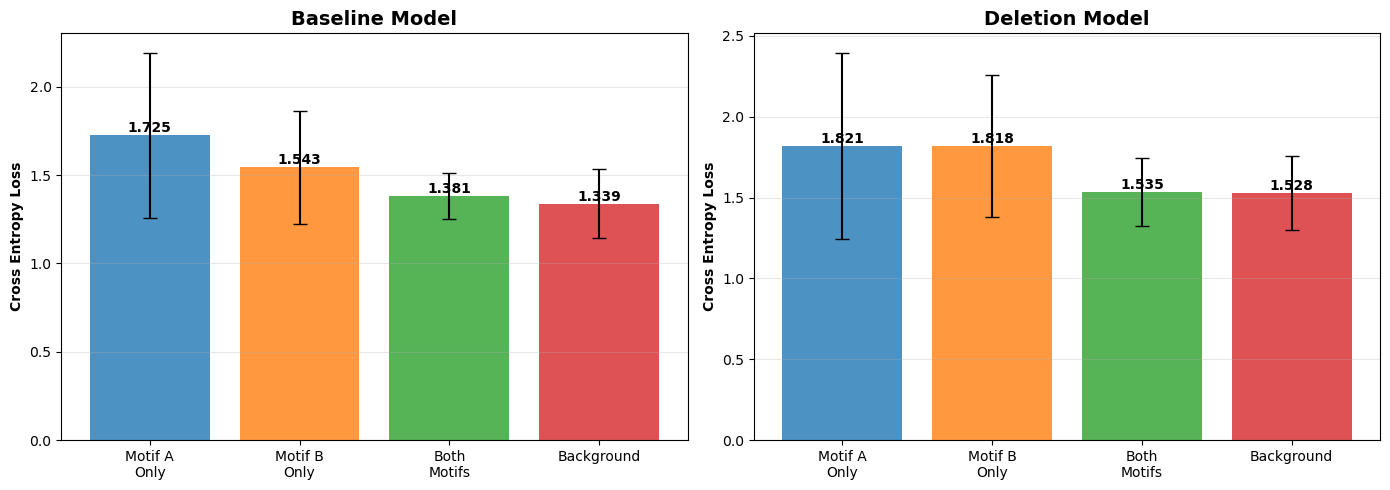


Baseline:
  Motif A only:  1.725 (n=8504)
  Motif B only:  1.543 (n=8570)
  Both motifs:   1.381 (n=2926)
  Background:    1.339 (n=19996)

Deletion:
  Motif A only:  1.821 (n=8504)
  Motif B only:  1.818 (n=8574)
  Both motifs:   1.535 (n=2922)
  Background:    1.528 (n=20000)


In [72]:
# Minimal cross-entropy analysis for all test data
import matplotlib.pyplot as plt
import numpy as np

def test_motifs_combined(seq, model, tokenizer, motif_list, device):
    """Test multiple motifs by masking ALL their positions at once"""
    tokens = [tokenizer._convert_token_to_id(c) for c in seq if tokenizer._convert_token_to_id(c) is not None]
    cls_id = tokenizer._convert_token_to_id('[CLS]')
    sep_id = tokenizer._convert_token_to_id('[SEP]')
    mask_id = tokenizer._convert_token_to_id('[MASK]')
    input_ids = [cls_id] + tokens + [sep_id]
    
    # Find all motif positions
    motif_positions = []  # List of (start, end, motif_tokens)
    for motif in motif_list:
        for m in re.finditer(motif, seq):
            start, end = m.span()
            motif_tokens = [tokenizer._convert_token_to_id(c) for c in motif]
            motif_positions.append((start, end, motif_tokens))
    
    if not motif_positions:
        return None
    
    # Create a single masked input with ALL motif positions masked
    masked = input_ids.copy()
    for start, end, _ in motif_positions:
        for i in range(end - start):
            if start + 1 + i < len(masked) - 1:
                masked[start + 1 + i] = mask_id
    
    # Get predictions
    with torch.no_grad():
        output = model(torch.tensor([masked], device=device), return_dict=True)
        logits = output.logits[0]
    
    # Calculate loss on ALL masked positions at once
    pred_logits = []
    truth_tokens = []
    for start, end, motif_tokens in motif_positions:
        for i, token in enumerate(motif_tokens):
            if start + 1 + i < len(logits) - 1:
                pred_logits.append(logits[start + 1 + i])
                truth_tokens.append(token)
    
    if not pred_logits:
        return None
    
    pred = torch.stack(pred_logits)
    truth = torch.tensor(truth_tokens, device=device)
    
    return F.cross_entropy(pred, truth).item()

def analyze_dataset(data, model, tokenizer, device):
    """Analyze all sequences - categorize by motif presence"""
    results = {'motif_a': [], 'motif_b': [], 'both': [], 'background': []}
    avg_motif_len = int((len(motifs[0]) + len(motifs[1])) / 2)
    
    for count, (idx, row) in enumerate(data.iterrows()):
        if count % 10 == 0:
            print(f"Processing {count}...")
        
        # if count > 100:
        #     break
        seq = row['sequences']
        
        # Check which motifs are present
        has_a = motifs[0] in seq
        has_b = motifs[1] in seq
        
        if has_a and has_b:
            # Sequence has BOTH motifs - mask ALL occurrences of BOTH at once
            loss = test_motifs_combined(seq, model, tokenizer, motifs, device)
            if loss is not None:
                results['both'].append(loss)
        elif has_a:
            # Only motif A - mask all occurrences of A
            loss = test_motifs_combined(seq, model, tokenizer, [motifs[0]], device)
            if loss is not None:
                results['motif_a'].append(loss)
        elif has_b:
            # Only motif B - mask all occurrences of B
            loss = test_motifs_combined(seq, model, tokenizer, [motifs[1]], device)
            if loss is not None:
                results['motif_b'].append(loss)
        
        # Test background (1 random chunk per sequence, avg motif length)
        motif_regions = set()
        for motif in motifs:
            for m in re.finditer(motif, seq):
                motif_regions.update(range(m.start(), m.end()))
        
        available = [pos for pos in range(len(seq)-avg_motif_len) if not any(p in motif_regions for p in range(pos, pos+avg_motif_len))]
        if available:
            start = np.random.choice(available)
            bg_chunk = seq[start:start+avg_motif_len*2]
            bg_loss = test_motifs_combined(seq, model, tokenizer, [bg_chunk], device)
            if bg_loss is not None:
                results['background'].append(bg_loss)
    
    return results

# Run analysis
print("Analyzing baseline model...")
baseline = analyze_dataset(test_data, model, tokenizer, device)
print("Analyzing deletion model...")
deletion = analyze_dataset(del_test_data, del_model, del_tokenizer, device)

# Print counts
print(f"\nBaseline - Motif A only: {len(baseline['motif_a'])}, Motif B only: {len(baseline['motif_b'])}, Both: {len(baseline['both'])}, Background: {len(baseline['background'])}")
print(f"Deletion - Motif A only: {len(deletion['motif_a'])}, Motif B only: {len(deletion['motif_b'])}, Both: {len(deletion['both'])}, Background: {len(deletion['background'])}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['Motif A\nOnly', 'Motif B\nOnly', 'Both\nMotifs', 'Background']

for ax, (name, res) in zip(axes, [('Baseline', baseline), ('Deletion', deletion)]):
    means = [np.mean(res[k]) if res[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
    stds = [np.std(res[k]) if res[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
    
    bars = ax.bar(categories, means, yerr=stds, capsize=5, alpha=0.8, 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    ax.set_title(f'{name} Model', fontweight='bold', fontsize=14)
    ax.set_ylabel('Cross Entropy Loss', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, m in zip(bars, means):
        if m > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                    f'{m:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('motif_cross_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
for name, res in [('Baseline', baseline), ('Deletion', deletion)]:
    print(f"\n{name}:")
    print(f"  Motif A only:  {np.mean(res['motif_a']):.3f} (n={len(res['motif_a'])})")
    print(f"  Motif B only:  {np.mean(res['motif_b']):.3f} (n={len(res['motif_b'])})")
    print(f"  Both motifs:   {np.mean(res['both']):.3f} (n={len(res['both'])})")
    print(f"  Background:    {np.mean(res['background']):.3f} (n={len(res['background'])})")


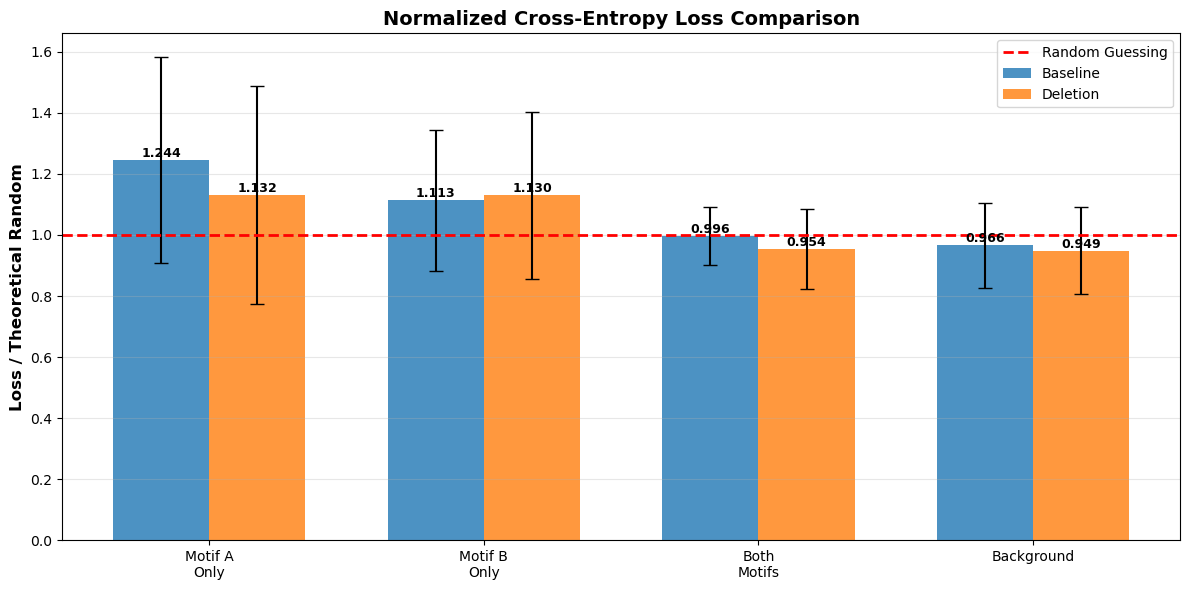

Theoretical: ln(4)=1.3863, ln(5)=1.6094
Baseline: A=1.244, B=1.113, Both=0.996, Bg=0.966
Deletion: A=1.132, B=1.130, Both=0.954, Bg=0.949


In [73]:
# Single normalized comparison plot
baseline_norm = {k: [l/np.log(4) for l in v] for k, v in baseline.items()}
deletion_norm = {k: [l/np.log(5) for l in v] for k, v in deletion.items()}

fig, ax = plt.subplots(figsize=(12, 6))
categories = ['Motif A\nOnly', 'Motif B\nOnly', 'Both\nMotifs', 'Background']
x = np.arange(len(categories))
width = 0.35

base_means = [np.mean(baseline_norm[k]) if baseline_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
del_means = [np.mean(deletion_norm[k]) if deletion_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
base_stds = [np.std(baseline_norm[k]) if baseline_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]
del_stds = [np.std(deletion_norm[k]) if deletion_norm[k] else 0 for k in ['motif_a', 'motif_b', 'both', 'background']]

bars1 = ax.bar(x - width/2, base_means, width, yerr=base_stds, capsize=5, label='Baseline', alpha=0.8)
bars2 = ax.bar(x + width/2, del_means, width, yerr=del_stds, capsize=5, label='Deletion', alpha=0.8)

ax.set_ylabel('Loss / Theoretical Random', fontweight='bold', fontsize=12)
ax.set_title('Normalized Cross-Entropy Loss Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Random Guessing')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('motif_cross_entropy_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Theoretical: ln(4)={np.log(4):.4f}, ln(5)={np.log(5):.4f}")
for name, res in [('Baseline', baseline_norm), ('Deletion', deletion_norm)]:
    print(f"{name}: A={np.mean(res['motif_a']):.3f}, B={np.mean(res['motif_b']):.3f}, "
          f"Both={np.mean(res['both']):.3f}, Bg={np.mean(res['background']):.3f}")
